In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import matplotlib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

matplotlib.rcParams["figure.figsize"] = (20, 10)

In [3]:
df1 = pd.read_csv("Bengaluru_House_Data.csv")
df1.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
df1.groupby("area_type")["area_type"].agg("count")

area_type
Built-up  Area          2418
Carpet  Area              87
Plot  Area              2025
Super built-up  Area    8790
Name: area_type, dtype: int64

## Feature Engineering

In [5]:
df2 = df1.drop(["area_type", "society", "balcony", "availability"], axis="columns")
df2.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [6]:
df2.isnull().sum()  # check for null values
df3 = df2.dropna()  # drop null values

In [7]:
df3["size"].unique()  # check for unique values in size column

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [8]:
df3["bhk"] = df3["size"].apply(lambda x: int(x.split(" ")[0]))

C:\Users\USER\AppData\Local\Temp\ipykernel_33272\540722847.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["bhk"] = df3["size"].apply(lambda x: int(x.split(" ")[0]))


In [9]:
df3[
    df3["bhk"] > 10
]  # check for houses with bhk greater than 10, which is not possible, so we can drop those rows

,location,size,total_sqft,bath,price,bhk
459,1 Giri Nagar,11 BHK,5000,9.0,360.0,11
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
1768,1 Ramamurthy Nagar,11 Bedroom,1200,11.0,170.0,11
3379,1Hanuman Nagar,19 BHK,2000,16.0,490.0,19
3609,Koramangala Industrial Layout,16 BHK,10000,16.0,550.0,16
3853,1 Annasandrapalya,11 Bedroom,1200,6.0,150.0,11
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43
4916,1Channasandra,14 BHK,1250,15.0,125.0,14
6533,Mysore Road,12 Bedroom,2232,6.0,300.0,12
7979,1 Immadihalli,11 BHK,6000,12.0,150.0,11


In [10]:
def is_float(x):  # function to check if the value can be converted to float or not
    try:
        float(x)
    except:
        return False
    return True

In [11]:
df3[~df3["total_sqft"].apply(is_float)].head(
    10
)  # check for unique values in total_sqft column which cannot be converted to float

,location,size,total_sqft,bath,price,bhk
30,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
122,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,56.800,2
410,Kengeri,1 BHK,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,2 BHK,1195 - 1440,2.0,63.770,2
648,Arekere,9 Bedroom,4125Perch,9.0,265.000,9
661,Yelahanka,2 BHK,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,4 Bedroom,3090 - 5002,4.0,445.000,4


In [12]:
# function to convert total_sqft column to float values
def convert_sqft_to_num(x):
    tokens = x.split("-")
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None

In [13]:
df4 = df3.copy()
df4["total_sqft"] = df4["total_sqft"].apply(convert_sqft_to_num)
df4.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,51.00,2


In [14]:
df5 = df4.copy()
df5["price_per_sqft"] = df5["price"] * 100000 / df5["total_sqft"]
df5.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [15]:
len(df5.location.unique())  # check for unique values in location column

1304

In [16]:
df5.location = df5.location.apply(
    lambda x: x.strip()
)  # remove extra spaces from location column
location_stats = (
    df5.groupby("location")["location"].agg("count").sort_values(ascending=False)
)
len(
    location_stats[location_stats <= 10]
)  # check how many locations have less than or equal to 10 data points
location_stats_less_than_10 = location_stats[location_stats <= 10]

In [17]:
# check for locations which have less than 10 data points
location_stats_less_than_10.head(10)
df5.location = df5.location.apply(
    lambda x: "other" if x in location_stats_less_than_10 else x
)

In [18]:
df5.head(10)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000
5,Whitefield,2 BHK,1170.0,2.0,38.00,2,3247.863248
6,Old Airport Road,4 BHK,2732.0,4.0,204.00,4,7467.057101
7,Rajaji Nagar,4 BHK,3300.0,4.0,600.00,4,18181.818182
8,Marathahalli,3 BHK,1310.0,3.0,63.25,3,4828.244275
9,other,6 Bedroom,1020.0,6.0,370.00,6,36274.509804


## Outlier Removal

In [19]:
df5[
    df5.total_sqft / df5.bhk < 300
].head()  # check for houses which have less than 300 sqft area per bhk, which is not possible, so we can drop those rows

,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274.509804
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333.333333
58,Murugeshpalya,6 Bedroom,1407.0,4.0,150.0,6,10660.980810
68,Devarachikkanahalli,8 Bedroom,1350.0,7.0,85.0,8,6296.296296
70,other,3 Bedroom,500.0,3.0,100.0,3,20000.000000


In [20]:
df6 = df5[~(df5.total_sqft / df5.bhk < 300)]

In [21]:
df6.price_per_sqft.describe()  # check for price per sqft column which has some outliers, so we can remove those outliers

count     12456.000000
mean       6308.502826
std        4168.127339
min         267.829813
25%        4210.526316
50%        5294.117647
75%        6916.666667
max      176470.588235
Name: price_per_sqft, dtype: float64

In [22]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby("location"):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[
            (subdf.price_per_sqft >= (m - st)) & (subdf.price_per_sqft <= (m + st))
        ]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

In [23]:
df7 = remove_pps_outliers(df6)
df7.shape

(10241, 7)

In [24]:
def plot_scatter_chart(df, location):
    bhk2 = df[(df.location == location) & (df.bhk == 2)]
    bhk3 = df[(df.location == location) & (df.bhk == 3)]
    plt.scatter(bhk2.total_sqft, bhk2.price_per_sqft, color="blue", label="2 BHK", s=50)
    plt.scatter(
        bhk3.total_sqft,
        bhk3.price_per_sqft,
        marker="+",
        color="green",
        label="3 BHK",
        s=50,
    )
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price Per Square Feet")
    plt.title(location)
    plt.legend()
    plot_scatter_chart(df7, "Rajaji Nagar")

In [25]:
# we can see that there are some 3 BHK houses which are cheaper than 2 BHK houses, which is not possible, so we can remove those outliers
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby("location"):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby("bhk"):
            bhk_stats[bhk] = {
                "mean": np.mean(bhk_df.price_per_sqft),
                "std": np.std(bhk_df.price_per_sqft),
                "count": bhk_df.shape[0],
            }
        for bhk, bhk_df in location_df.groupby("bhk"):
            stats = bhk_stats.get(bhk - 1)
            if stats and stats["count"] > 5:
                exclude_indices = np.append(
                    exclude_indices,
                    bhk_df[bhk_df.price_per_sqft < (stats["mean"])].index.values,
                )
    return df.drop(exclude_indices, axis="index")


df8 = remove_bhk_outliers(df7)
df8.shape

(7329, 7)

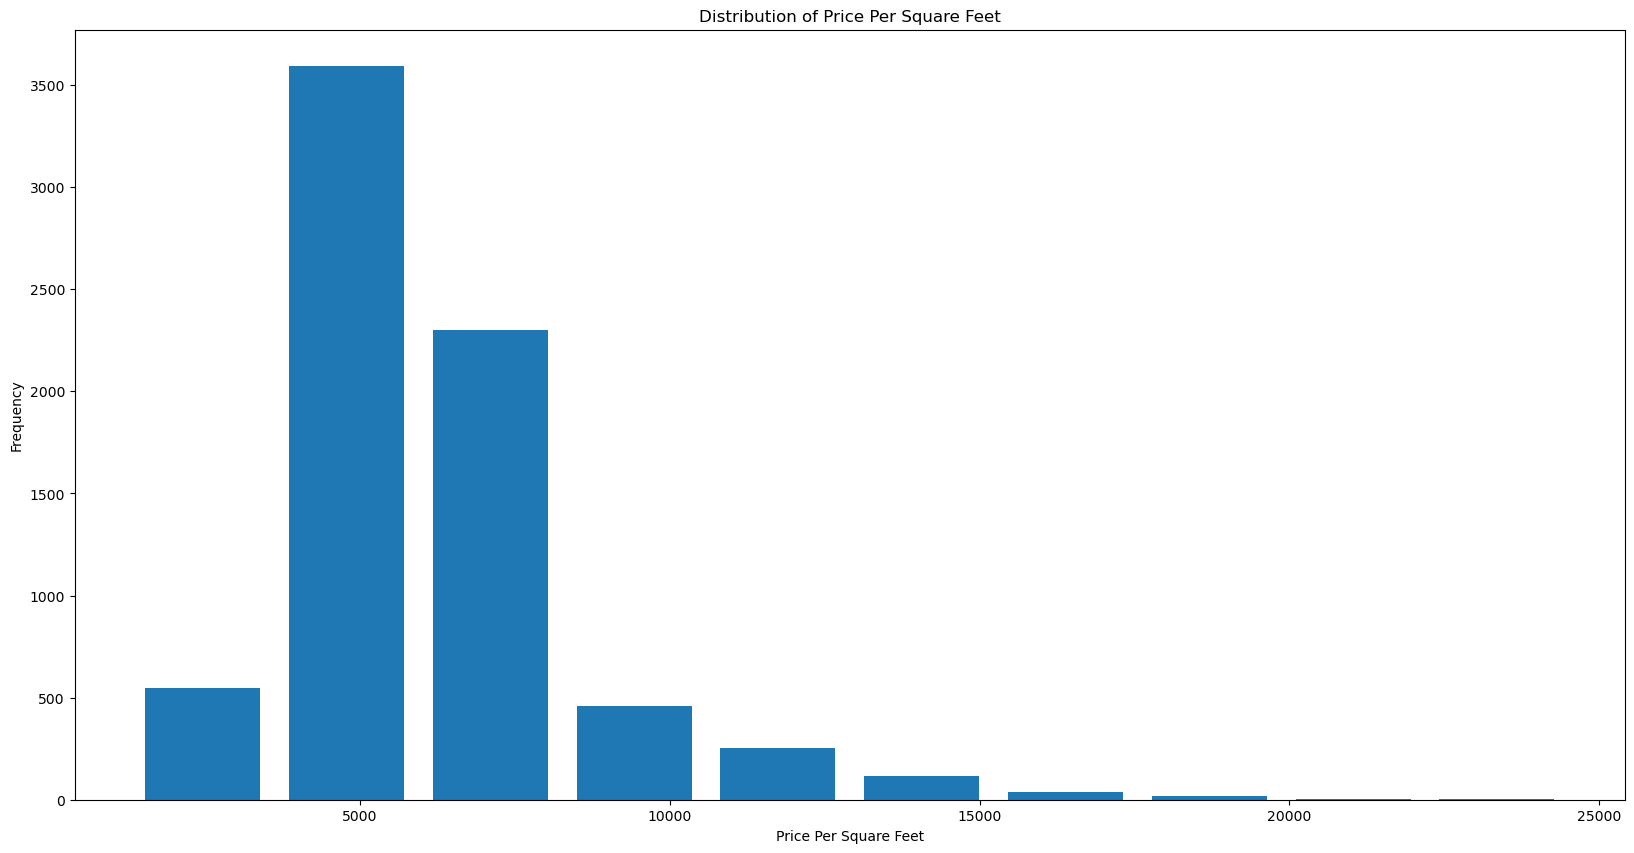

In [26]:
plt.hist(df8.price_per_sqft, rwidth=0.8)
plt.xlabel("Price Per Square Feet")
plt.ylabel("Frequency")
plt.title("Distribution of Price Per Square Feet")
plt.show()

In [27]:
df8.bath.unique()  # check for unique values in bath column which has some outliers, so we can remove those outliers
df9 = df8[df8.bath < df8.bhk + 2]  # check for houses which have more than

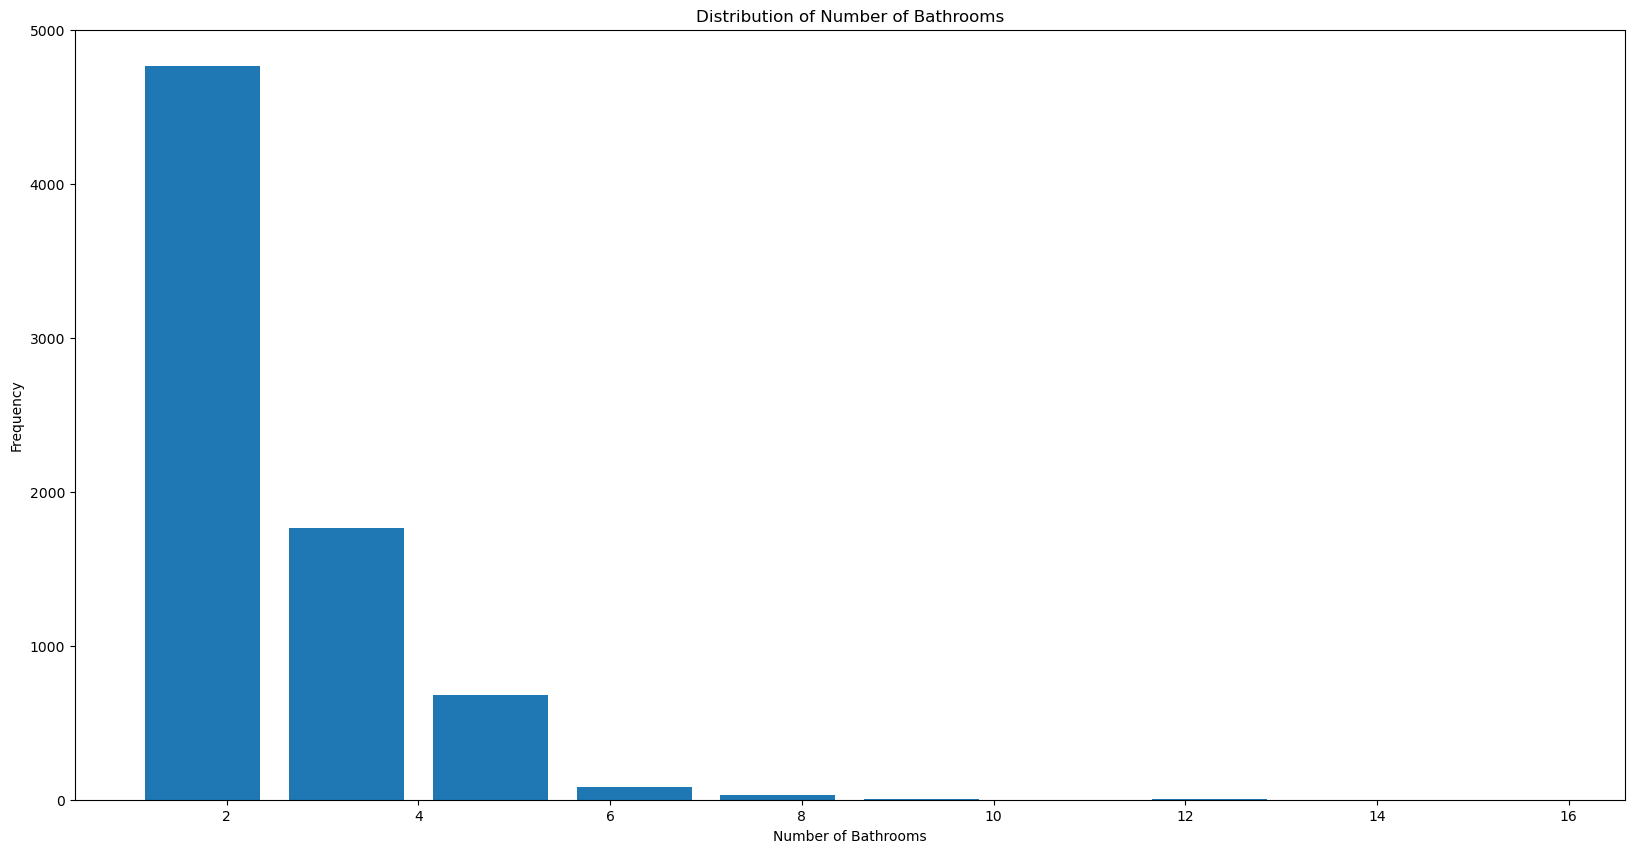

In [28]:
plt.hist(df8.bath, rwidth=0.8)
plt.xlabel("Number of Bathrooms")
plt.ylabel("Frequency")
plt.title("Distribution of Number of Bathrooms")
plt.show()

In [29]:
df9.shape

(7251, 7)

## Model Building

In [30]:
df10 = df9.drop(["size", "price_per_sqft"], axis="columns")
df10.head()

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3
3,1st Block Jayanagar,1200.0,2.0,130.0,3
4,1st Block Jayanagar,1235.0,2.0,148.0,2


In [31]:
# Create dummy variables for the 'location' column
dummies = pd.get_dummies(df10.location)

In [32]:
df11 = pd.concat([df10, dummies.drop("other", axis="columns")], axis="columns")

In [33]:
df12 = df11.drop("location", axis="columns")
df12.head()
X = df12.drop("price", axis="columns")
y = df12.price

In [34]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)

In [35]:
lr_clf = LinearRegression()
lr_clf.fit(x_train, y_train)
lr_clf.score(x_test, y_test)

0.8452277697874272

## K-fold Validation

In [36]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
cross_val_score(LinearRegression(), X, y, cv=cv)

array([0.82430186, 0.77166234, 0.85089567, 0.80837764, 0.83653286])

## GridSearchcv

In [40]:
import pandas as pd
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, ShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def find_best_model_using_gridsearchcv(X, y):

    algos = {
        "linear_regression": {
            "model": Pipeline(
                [("scaler", StandardScaler()), ("lr", LinearRegression())]
            ),
            "params": {"lr__fit_intercept": [True, False]},
        },
        "lasso": {
            "model": Pipeline([("scaler", StandardScaler()), ("lasso", Lasso())]),
            "params": {
                "lasso__alpha": [1, 2],
                "lasso__selection": ["random", "cyclic"],
            },
        },
        "decision_tree": {
            "model": DecisionTreeRegressor(),
            "params": {
                "criterion": ["squared_error", "friedman_mse"],
                "splitter": ["best", "random"],
                "max_depth": [None, 5, 10],
            },
        },
    }

    scores = []
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

    for algo_name, config in algos.items():
        gs = GridSearchCV(
            config["model"],
            config["params"],
            cv=cv,
            return_train_score=False,
            n_jobs=-1,
        )

        gs.fit(X, y)

        scores.append(
            {
                "model": algo_name,
                "best_score": gs.best_score_,
                "best_params": gs.best_params_,
            }
        )

    return pd.DataFrame(scores, columns=["model", "best_score", "best_params"])


find_best_model_using_gridsearchcv(X, y)

,model,best_score,best_params
0,linear_regression,0.818354,{'lr__fit_intercept': True}
1,lasso,0.790561,"{'lasso__alpha': 1, 'lasso__selection': 'cyclic'}"
2,decision_tree,0.742288,"{'criterion': 'friedman_mse', 'max_depth': 10,..."


In [ ]:
# Based on the above results, we can see that Linear Regression is the best model for our dataset, so we can use that model to predict the price of a house based on the location, sqft, bath and bhk.
def predict_price(location, sqft, bath, bhk):
    loc_index = np.where(X.columns == location)[0][0]
    x = np.zeros(len(X.columns))
    x[0] = sqft
    x[1] = bath
    x[2] = bhk
    if loc_index >= 0:
        x[loc_index] = 1
    return lr_clf.predict([x])[0]

In [42]:
# Now we can use the above function to predict the price of a house based on the location, sqft, bath and bhk.
import pickle

with open("banglore_home_prices_model.pickle", "wb") as f:
    pickle.dump(lr_clf, f)

In [43]:
# We also need to save the columns used in our model, so that we can use those columns while making predictions from the saved model.
import json

columns = {"data_columns": [col.lower() for col in X.columns]}
with open("columns.json", "w") as f:
    f.write(json.dumps(columns))